In [4]:
import pandas as pd
from tqdm import tqdm 
import scanpy as sc
import sys
import os 
import logging 
from omegaconf import OmegaConf, DictConfig
from hydra import initialize, compose
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder
import torch
import numpy as np
from pathlib import Path 
import torch.nn.functional as F
import matplotlib.pyplot as plt

from labcompass.constants import DataFields
sys.path.insert(0, "../../shared_utils/")
from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn
)

logger = logging.getLogger(__name__)

In [5]:
protocol_cols = ['gm-csf_[ng_ml]', 
                 'tpo_[ng_ml]',
                 'sr1_[nm]', 
                 'um171_[nm]',
                 'um729_[µm]', 
                 'scf_[ng_ml]',
                 'butyzamide_[nm]',
                 'retinoic_acid_[µm]', 
                 'ldl_[ng_ml]', 
                 'il3_[ng_ml]', 
                 'o2_[%]',
                 'days_of_culture']

In [6]:
obs_l1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad").obs
obs_l2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2p5/replicate/adata_500k.h5ad").obs

to_keep = [
            "239",
            "240",
            "248",
            "241",
            "242",
            "249"]
to_keep = [str(i) for i in to_keep]

obs_l2 = obs_l2.loc[obs_l2.experiment_number.isin(to_keep)]

experiment_numbers = np.concatenate([obs_l1.experiment_number, obs_l2.experiment_number])

In [7]:
obs_l1 = obs_l1.loc[:, protocol_cols].drop_duplicates().values.astype(float)
obs_l2 = obs_l2.loc[:, protocol_cols].drop_duplicates().values.astype(float)

In [8]:
adata_l1 = sc.AnnData(X=np.concatenate([obs_l1, obs_l2]))
adata_l1.obs = {"Loop": ["Loop1" for _ in range(len(obs_l1))] + ["Loop2" for _ in range(len(obs_l2))]}

In [9]:
sc.pp.log1p(adata_l1)
sc.tl.pca(adata_l1)
sc.pp.neighbors(adata_l1)
sc.tl.umap(adata_l1)

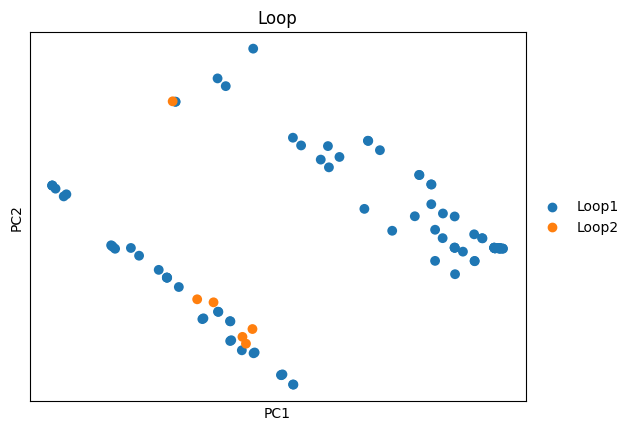

In [10]:
sc.pl.pca(adata_l1, s=200, color="Loop")

## Compute the decrease of uncertainty of forward model for subsequent opt

In [11]:
def uncertainty_quantification(
    forward_model,
    base_cfg,
    X_candidates, 
    target_cell_types, 
    n_noise_samples,
    n_populations, 
    cell_type_column):
    
    protocol_columns = base_cfg["annotation"]["protocol_columns"]

    ct_le = LabelEncoder()
    ct_values = target_prediction_model.train_data.adata.obs[cell_type_column].values
    ct_le.fit(ct_values)
    classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 
    print(classes)

    # Take cell type index 
    cell_type_index = classes.index(target_cell_types)
    ct_safe_string = target_cell_types.replace("/", ":") # cell type dir

    X_candidates = torch.from_numpy(X_candidates).float().to("cuda")
    X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
    condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
    batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}

    forward_out = forward_model.predict(
        batch_dict,
        no_grad=True,
        fix_noise=False,
        num_time_steps=100
    )
    
    y_pred = forward_out["target_prediction_data"][cell_type_column].view(X_candidates_add.shape[0],
                                                                     n_populations,
                                                                     -1,
                                                                     len(classes))  
    y_pred_softmax = F.softmax(y_pred, dim=-1)

    # Take the mean proportions 
    y_pred_mean = y_pred.mean(2)  # no_candidates x no_populations x no_cell_types 
    y_pred_softmax = y_pred_softmax.mean(2)  # no_candidates x no_populations x no_cell_types 
    print(y_pred_softmax[:, :, 21].mean())

    # Collect cell type of interest 
    y_pred_ct_std = y_pred_softmax[..., cell_type_index].std(1).detach().cpu().numpy()  # standard deviation prob cell type of interest 
    # Calculate loss
    y_target_ct = np.zeros((1, len(classes)))
    y_target_ct[:, cell_type_index] = 1.0
    y_target_ct = torch.from_numpy(y_target_ct)
    y_target_ct = y_target_ct.unsqueeze(0).to("cuda")  # 1 x 1 x no_cell_types
    
    logger.info("Compute loss function")
    loss_fn = lambda pred, target: -torch.sum(target*torch.nn.functional.log_softmax(pred, dim=-1), dim=-1)
    with torch.no_grad():
        loss = loss_fn(y_pred_mean, y_target_ct)  # no_candidates x no_populations

    loss_std = loss.std(1).detach().cpu().numpy()  # no_candidates
    return loss_std

In [12]:
base_config_path = "../../inverse/loss_guidance/config/"
base_config_name = "run_inverse"
target_cell_types = "EryPro"
n_noise_samples = 2000
n_populations = 10
cell_type_column = "cell_type" 

# Initialize paths 
with initialize(config_path=base_config_path, version_base=None):
    cfg_l1 = compose(
        config_name=base_config_name,
        overrides=[f"paths=loop1", 
                   f"loss=default",
                   f"annotation=bloodplus", 
                   f"constraints=default_all_cols"])

with initialize(config_path=base_config_path, version_base=None):
    cfg_l2 = compose(
        config_name=base_config_name,
        overrides=[f"paths=loop2p5_replicate", 
                   f"loss=loop2p5_replicate",
                   f"annotation=bloodplus", 
                   f"constraints=default_all_cols"])

## Predict loop0 

In [ ]:
forward_model, (_, target_prediction_model) = get_forward_model(cfg_l1, logger=logger)

In [ ]:
unc_l1_pred = []

for _ in tqdm(range(5)):
    unc_l1_pred.append(uncertainty_quantification(
        forward_model, 
        cfg_l1,
        adata_l1.X, 
        target_cell_types, 
        n_noise_samples,
        n_populations, 
        cell_type_column))

In [ ]:
unc_l1_pred = np.stack(unc_l1_pred, axis=0).mean(0)

In [ ]:
del forward_model
del target_prediction_model

## Predict loop1

In [ ]:
forward_model, (_, target_prediction_model) = get_forward_model(cfg_l2, logger=logger)

In [ ]:
unc_l2_pred = []

for _ in tqdm(range(5)):
    unc_l2_pred.append(uncertainty_quantification(
        forward_model, 
        cfg_l1,
        adata_l1.X, 
        target_cell_types, 
        n_noise_samples,
        n_populations, 
        "cell_type_reannot_final"))

In [ ]:
unc_l2_pred = np.stack(unc_l2_pred, axis=0).mean(0)

In [ ]:
del forward_model
del target_prediction_model

# Plot both uncertanties and also new recipes

In [ ]:
unc_delta = unc_l1_pred - unc_l2_pred

## Deltas

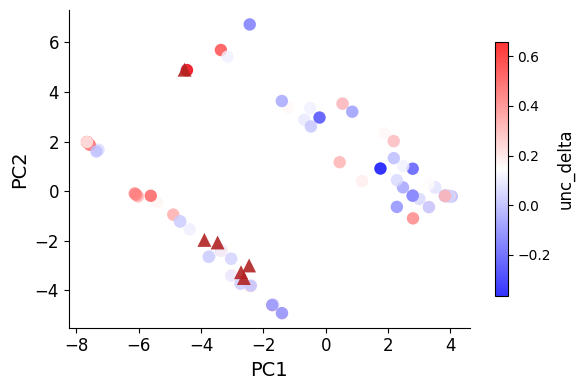

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))

# Split by Loop
mask_loop1 = adata_l1.obs["Loop"] == "Loop1"
mask_loop2 = adata_l1.obs["Loop"] == "Loop2"

pca_coords = adata_l1.obsm["X_pca"]

# Loop0: colored by unc_delta (continuous colormap)
sc_plot = ax.scatter(
    pca_coords[mask_loop1, 0],
    pca_coords[mask_loop1, 1],
    c=unc_delta[mask_loop1],
    cmap="bwr",
    s=80,
    alpha=0.8,
    edgecolor="none",
    marker="o",
    label="Loop0",
)

# Loop1: solid red, different marker, on top
ax.scatter(
    pca_coords[mask_loop2, 0],
    pca_coords[mask_loop2, 1],
    color="firebrick",
    s=100,
    alpha=0.9,
    edgecolor="none",
    marker="^",
    label="Loop1",
    zorder=3,
)

# Colorbar for the uncertainty values
cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.8)
cbar.set_label("unc_delta", fontsize=12)

ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(fontsize=11, loc="best", frameon=True)

plt.tight_layout()
plt.show()

## Deltas

In [34]:
adata_l1.obs

,Loop
0,Loop1
1,Loop1
2,Loop1
3,Loop1
4,Loop1
...,...
104,Loop2
105,Loop2
106,Loop2
107,Loop2


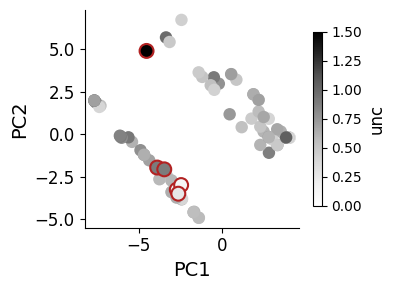

In [35]:
fig, ax = plt.subplots(figsize=(4, 3))
# Split by Loop
mask_loop1 = adata_l1.obs["Loop"] == "Loop1"
# mask_loop2 = adata_l1.obs["Loop"] == "Loop2"


pca_coords = adata_l1.obsm["X_pca"]
# Loop1: colored by unc_l1_pred (continuous colormap)
sc_plot = ax.scatter(
    pca_coords[mask_loop1, 0],
    pca_coords[mask_loop1, 1],
    c=unc_l1_pred[mask_loop1],
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=80,
    edgecolor="none",
    marker="o",
    label="Loop1",
)
# Loop2: colored the same way, but circled in firebrick
ax.scatter(
    pca_coords[mask_loop2, 0],
    pca_coords[mask_loop2, 1],
    c=unc_l1_pred[mask_loop2],
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=100,
    edgecolor="firebrick",
    linewidth=1.5,
    marker="o",
    label="Loop2",
    zorder=3,
)
# Colorbar for the uncertainty values
cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.8)
cbar.set_label("unc", fontsize=12)
ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(fontsize=11, loc="best", frameon=True)
plt.tight_layout()
plt.savefig("pca_trans_1_to_2_plot_1.png", dpi=700, bbox_inches="tight")
plt.show()

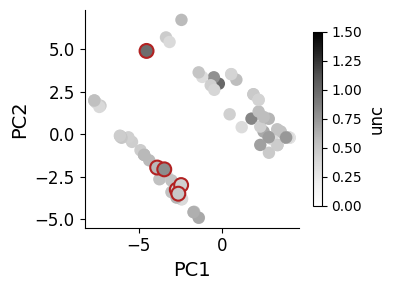

In [36]:
fig, ax = plt.subplots(figsize=(4, 3))
# Split by Loop
mask_loop1 = adata_l1.obs["Loop"] == "Loop1"
mask_loop2 = adata_l1.obs["Loop"] == "Loop2"
pca_coords = adata_l1.obsm["X_pca"]
# Loop1: colored by unc_l2_pred (continuous colormap)
sc_plot = ax.scatter(
    pca_coords[mask_loop1, 0],
    pca_coords[mask_loop1, 1],
    c=unc_l2_pred[mask_loop1],
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=80,
    edgecolor="none",
    marker="o",
    label="Loop1",
)
# Loop2: colored the same way, but circled in firebrick
ax.scatter(
    pca_coords[mask_loop2, 0],
    pca_coords[mask_loop2, 1],
    c=unc_l2_pred[mask_loop2],
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=100,
    edgecolor="firebrick",
    linewidth=1.5,
    marker="o",
    label="Loop2",
    zorder=3,
)
# Colorbar for the uncertainty values
cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.8)
cbar.set_label("unc", fontsize=12)
ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(fontsize=11, loc="best", frameon=True)
plt.tight_layout()
plt.savefig("pca_trans_1_to_2_plot_2.png", dpi=700, bbox_inches="tight")
plt.show()